In [ ]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from dssp import DSSPFile
from files.pdb import cif_to_pdba

import requests
import ast

%load_ext autoreload 
%autoreload 2

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
COLABFOLD_OUTPUT_DIR = '../data/genes/colabfold/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 1].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_1.faa')
# subprocess.run('muscle -align ../data/genes/cluster_1.faa -output ../data/genes/cluster_1.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_1 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_1 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_175
orfm.bz_1.1_148
orfm.bz_2.1_34
orfm.bz_3.1_50
orfm.bz_4.1_164
orfm.bz_5.1_140
orfm.bz_7.1_180
orfm.bz_8.1_206
orfm.bz_9.1_49
orfm.bz_10.1_18
orfm.bz_11.1_39

Minimum cluster_1 gene length: 138
Maximum cluster_1 gene length: 153


In [3]:
outputs = [AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)) for gene_id in genes_df.index]
# outputs = [ColabFoldOutput(os.path.join(COLABFOLD_OUTPUT_DIR, get_genome_id(gene_id), gene_id)) for gene_id in genes_df.index]
# Pretty solid improvements in the structures using the custom MSAs! Though confidence is still fairly weak. 
for output in outputs:
    print(output.name, output.get_ptms(best_model=True))

# Copy structures over for DALI search via the web interface. 
for output in outputs:
    output_path = os.path.join('/home/prichter/Downloads/', f'{output.name}.pdb')
    cif_to_pdb(output.best_model_path, output_path=output_path)

orfm.bz_0.1_175 0.46
orfm.bz_1.1_148 0.49
orfm.bz_2.1_34 0.48
orfm.bz_3.1_50 0.5
orfm.bz_4.1_164 0.45
orfm.bz_5.1_140 0.48
orfm.bz_7.1_180 0.4
orfm.bz_8.1_206 0.46
orfm.bz_9.1_49 0.45
orfm.bz_10.1_18 0.47
orfm.bz_11.1_39 0.49


In [4]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)


Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_4 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [ ]:
msa = MSAFile.from_file('../data/genes/cluster_1.afa')
dssp_msa = map_dssp_to_msa(msa, dssp_output_dir='../data/genes/dssp')

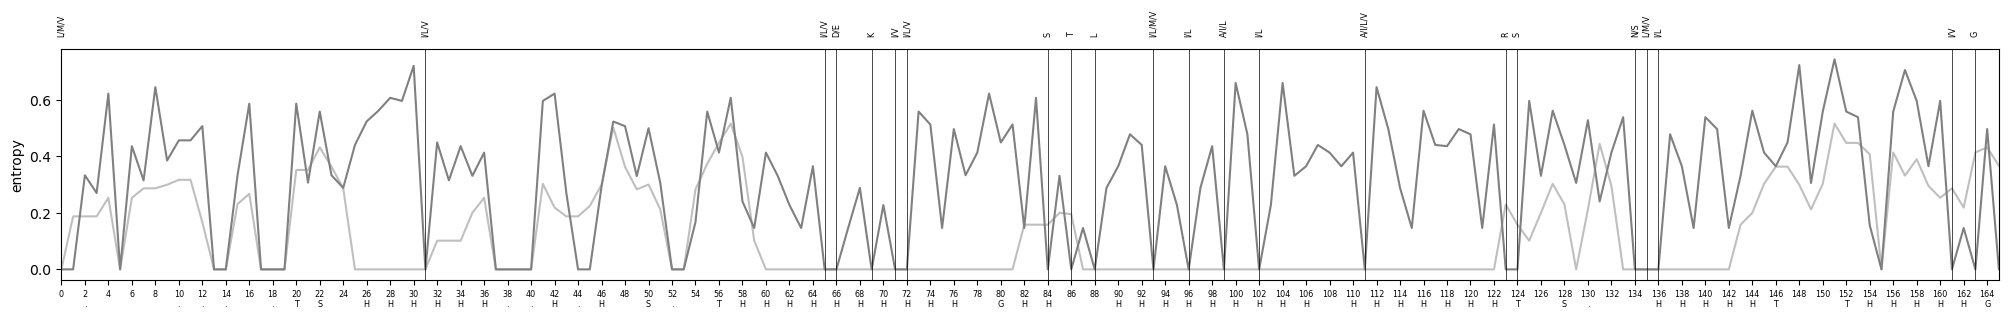

In [6]:
def get_entropy(MSAFile, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in MSAFile.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSAFile.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSAFile.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))
MAX_ENTROPY = 0.1
# x_min, x_max = 240, 270

x_min, x_max = 0,165 
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
dssp_entropy = get_entropy(dssp_msa)

ax.plot(np.arange(len(entropy)), entropy, color='gray')
ax.plot(np.arange(len(dssp_entropy)), dssp_entropy, color='gray', alpha=0.5)

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]

ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

# H, D, E, and C are potentially metal-binding. 

In [7]:

FOLDSEEK_FIELD_MAP = dict()
FOLDSEEK_FIELD_MAP['query'] = 'query_id'
FOLDSEEK_FIELD_MAP['target'] = 'target_id'
FOLDSEEK_FIELD_MAP['evalue'] = 'e_value'
FOLDSEEK_FIELD_MAP['gapopen'] = 'num_gaps'
FOLDSEEK_FIELD_MAP['pident'] = 'percent_identity'
FOLDSEEK_FIELD_MAP['fident'] = 'fraction_identical'
FOLDSEEK_FIELD_MAP['nident'] = 'num_identical'
FOLDSEEK_FIELD_MAP['qstart'] = 'query_start'
FOLDSEEK_FIELD_MAP['qend'] = 'query_end'
FOLDSEEK_FIELD_MAP['qlen'] = 'query_length'
FOLDSEEK_FIELD_MAP['tstart'] = 'target_start'
FOLDSEEK_FIELD_MAP['tend'] = 'target_end'
FOLDSEEK_FIELD_MAP['tlen'] = 'target_length'
FOLDSEEK_FIELD_MAP['alnlen'] = 'alignment_length'
FOLDSEEK_FIELD_MAP['bits'] = 'bit_score'
FOLDSEEK_FIELD_MAP['cigar'] = 'cigar'
FOLDSEEK_FIELD_MAP['qseq'] = 'query_seq'
FOLDSEEK_FIELD_MAP['tseq'] = 'target_seq'
FOLDSEEK_FIELD_MAP['qheader'] = 'query_header'
FOLDSEEK_FIELD_MAP['theader'] = 'target_header'
FOLDSEEK_FIELD_MAP['qaln'] = 'query_alignment'
FOLDSEEK_FIELD_MAP['taln'] = 'target_alignment'
FOLDSEEK_FIELD_MAP['mismatch'] = 'num_mismatches'
FOLDSEEK_FIELD_MAP['qcov'] = 'query_coverage'
FOLDSEEK_FIELD_MAP['tcov'] = 'target_coverage'
FOLDSEEK_FIELD_MAP['taxid'] = 'taxonomy_id'
FOLDSEEK_FIELD_MAP['taxname'] = 'taxonomy'
FOLDSEEK_FIELD_MAP['taxlineage'] = 'lineage'
FOLDSEEK_FIELD_MAP['lddt'] = 'lddt'
FOLDSEEK_FIELD_MAP['lddtfull'] = 'lddt_full'
FOLDSEEK_FIELD_MAP['qtmscore'] = 'query_tm_score'
FOLDSEEK_FIELD_MAP['ttmscore'] = 'target_tm_score'
FOLDSEEK_FIELD_MAP['alntmscore'] = 'alignment_tm_score'
FOLDSEEK_FIELD_MAP['rmsd'] = 'rmsd'
FOLDSEEK_FIELD_MAP['prob'] = 'probability'

FOLDSEEK_FIELDS = 'query target evalue gapopen pident fident nident qstart qend qlen tstart tend tlen alnlen bits cigar qseq tseq qheader theader qaln taln mismatch qcov tcov taxid taxname taxlineage lddt lddtfull qtmscore ttmscore alntmscore rmsd prob'
FOLDSEEK_FIELDS = [FOLDSEEK_FIELD_MAP.get(field) for field in FOLDSEEK_FIELDS.split(' ')]

foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]


target_header_map = dict()
target_header_map['A0A649VKB1'] = 'RNA polymerase sigma factor'
target_header_map['A0A8S5VJW2'] = 'Not named'
target_header_map['A0A516M315'] = 'Not named'
target_header_map['A0A0B4ZZ91'] = 'DUF5132 domain-containing protein' # See https://www.ebi.ac.uk/interpro/entry/pfam/PF17195/
target_header_map['H6SU45'] = 'Uncharacterized protein'
target_header_map['S5VZJ8'] = 'Uncharacterized protein'
target_header_map['A0A2I2L3Z6'] = 'Nucleotidyltransferase'
target_header_map['A0A7G9U8E2'] = 'Uncharacterized protein'
target_header_map['A0A1S6L1J1'] = 'Uncharacterized protein'
target_header_map['A0A2I7QII9'] = 'Uncharacterized protein'
target_header_map['A0A6J5NUG'] = 'Uncharacterized protein'
target_header_map['A0A6J5M230'] = 'Bacteriophage holin family'
target_header_map['A0A6J5NUG2'] = 'Uncharacterized protein'
target_header_map['A0A8S0I5L0'] = 'Not named'

foldseek_search_df['target_header'] = foldseek_search_df.target_header.apply(lambda header : target_header_map.get(header, header))

In [8]:
filters = dict()
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')

foldseek_search_df = apply_filters(filters, foldseek_search_df)


apply_filters: 3378 entries removed by low_tm_score.
apply_filters: 75 entries removed by short_alignment.
apply_filters: 13 entries removed by synthetic.


In [34]:

DALI_FIELD_MAP = dict()
DALI_FIELD_MAP['query'] = 'query_id'
DALI_FIELD_MAP['sbjct'] = 'target_id'
DALI_FIELD_MAP['seq_identity'] = 'percent_identity'
DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
DALI_FIELD_MAP['sbject_length'] = 'target_length'
DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
DALI_FIELD_MAP['compressed_sbjct_dssp'] = 'target_dssp'
DALI_FIELD_MAP['sstarts'] = 'target_starts'
DALI_FIELD_MAP['lengths'] = 'alignment_lengths'
DALI_FIELD_MAP['qstarts'] = 'query_starts'
DALI_FIELD_MAP['all_pfam'] = 'pfam_data'
DALI_FIELD_MAP['ali_length'] = 'alignment_length'

dali_search_df.duplicated(['query_id', 'target_id']).sum()

np.int64(0)

In [43]:
dali_search_df = pd.concat([pd.read_csv(path, sep='\t', comment='#').assign(path=path) for path in glob.glob('../data/genes/dali/*')]).drop(columns=['query'])
dali_search_df['query_id'] = [os.path.basename(path).replace('.tsv', '') for path in dali_search_df.path]
dali_search_df.columns = dali_search_df.columns.str.replace('-', '_')
dali_search_df = dali_search_df.rename(columns=DALI_FIELD_MAP)


def get_pfam_data(df):
    ''''''
    fields = ['pfam', 'pfam_group', 'pfam_start', 'pfam_stop', 'pfam_e_value']

    df_ = list()
    for row in df.itertuples():
        data = ast.literal_eval(row.pfam_data)
        rows = [dict(zip(fields, entry)) for entry in data]
        for row_ in rows:
            row_['pfam_hit_in_alignment'] = not ((row_['pfam_start'] > row.target_stop) or (row_['pfam_stop'] < row.target_start))
            # Need to include both the query and target ID so that the pfam_hit_in_alignment field is relevant.
            row_['target_id'] = row.target_id
            row_['query_id'] = row.query_id
        df_ += rows
    return pd.DataFrame(df_)


def get_alignment_data(df):
    ''''''
    parse = lambda idxs : ast.literal_eval(re.sub(r'(?<=\d)\s+(?=\d)', ', ', idxs))
    df['query_starts'] = df['query_starts'].apply(parse)
    df['target_starts'] = df['target_starts'].apply(parse)
    df['alignment_lengths'] = df['alignment_lengths'].apply(parse)

    df_ = list()
    for row in df.itertuples():
        row_ = {'query_id':row.query_id, 'target_id':row.target_id}
        row_['query_start'], row_['query_stop'] = min(row.query_starts), max(row.query_starts) + row.alignment_lengths[-1]
        row_['target_start'], row_['target_stop'] = min(row.target_starts), max(row.target_starts) + row.alignment_lengths[-1]
        df_.append(row_)

    return pd.DataFrame(df_)


dali_search_df = dali_search_df.merge(get_alignment_data(dali_search_df), on=['query_id', 'target_id'], how='left')
dali_search_df = dali_search_df.merge(get_pfam_data(dali_search_df), on=['query_id', 'target_id'], how='left')


filters = dict()
filters['low_z_score'] = dali_search_df.z_score < 3
filters['high_rmsd'] = dali_search_df.rmsd > 5


apply_filters(filters, dali_search_df).sort_values('alignment_length').iloc[-20:]



apply_filters: 13057 entries removed by low_z_score.
apply_filters: 14809 entries removed by high_rmsd.


,database,target_id,z_score,rmsd,alignment_length,sbjct_length,percent_identity,target_seq,target_dssp,description,...,query_start,query_stop,target_start,target_stop,pfam,pfam_group,pfam_start,pfam_stop,pfam_e_value,pfam_hit_in_alignment
6446,PDB,4xwjA,3.4,3.3,74,153,7,TSMLNQLDNLTERVRGSNKLVDRWLHVRKHLLVAYYNLVGIKPGKE...,1L13H4L21H8L4H1L20H1L8H3L26H1L8H2L31H1L,MOLECULE: REGULATOR OF SIGMA D;,...,45,130,16,154,PF04353,PF04353,3.0,149.0,7.900000e-52,True
6447,PDB,4xwjA,3.4,3.3,74,153,7,TSMLNQLDNLTERVRGSNKLVDRWLHVRKHLLVAYYNLVGIKPGKE...,1L13H4L21H8L4H1L20H1L8H3L26H1L8H2L31H1L,MOLECULE: REGULATOR OF SIGMA D;,...,45,130,16,154,PF04353,PF04353,3.0,151.0,5.500000e-50,True
6974,PDB,8dt0A,3.1,3.7,74,140,5,EEEELEELAKELEKILRDEEGHLRKLKEALAEGLGDAEEAAELFRA...,1L30H5L26H6L34H2L35H1L,MOLECULE: SCAFFOLDING PROTEIN FUNCTIONAL SITES;,...,42,130,1,140,NaN,NaN,NaN,NaN,NaN,NaN
15391,PDB,9k8eA,3.8,3.6,74,228,8,GTMEELARRVGRAIERYLNGEINEVELALAVGHIFRDYGLEELHEI...,2L16H5L14H3L11H5L15H2L14H3L18H5L21H3L23H5L19H4...,MOLECULE: CAGE-T32-ZN1-HEHE-35;,...,3,105,37,140,NaN,NaN,NaN,NaN,NaN,NaN
7042,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF14529,CL0530,105.0,228.0,1.100000e-09,True
7043,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF00078,CL0027,512.0,768.0,1.000000e-45,True
7041,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF03372,CL0530,6.0,225.0,8.600000e-21,True
7045,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF14529,CL0530,104.0,229.0,7.800000e-08,True
7044,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF03372,CL0530,6.0,225.0,5.900000e-19,True
7046,PDB,9k6iA,3.1,4.2,74,1270,5,SHITILTLNINGLNSAIKRHRLASWIKSQDPSVCCIQETHLTCRDT...,1L8E6L14H3L5E5L6H7L5E8L5E5L8E5L8E3L8E5L11H8L6E...,MOLECULE: LINE-1 RETROTRANSPOSABLE ELEMENT ORF...,...,60,150,15,1178,PF00078,CL0027,512.0,768.0,7.000000e-44,True


In [10]:
# # First want to evaluate the quality of the ColabFold structures. 
# COLABFOLD_DIR = '../data/genes/colabfold/'
# COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
# COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
# COLABFOLD_PLDDTS = dict()

# for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
#     if get_gene_id(path) not in genes_df.index.values: 
#         continue 

#     with open(path, 'r') as f:
#         scores = json.load(f)
#         plddts = np.array(scores['plddt'])
#         COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# # cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# # palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# # fig, ax = plt.subplots(figsize=(10, 3.5))
# # for gene_id, plddts in COLABFOLD_PLDDTS.items():
# #     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# # ax.set_xlim(xmin=0, xmax=180)
# # ax.set_ylabel('pLDDT')
# # ax.set_xlabel('position')
# # plt.show()

# pattern = '(' + '|'.join(genes_df.index) + ')' + r'_relaxed_rank_001_alphafold2_ptm_model_\d_seed_\d\d\d\.pdb'
# paths = [path for path in glob.glob(os.path.join(COLABFOLD_DIR, '**', '*')) if (re.search(pattern, path) is not None)]
# for path in paths:
#     output_path = os.path.join('/home/prichter/Documents/banfield/betazoid/data/genes/metal3d/', f'{get_gene_id(path)}')
#     cmd = f'metal3d --pdb {os.path.abspath(path)} --metalbinding --writeprobes --probefile {output_path}.pdb --maxp --writecube --cubefile {output_path}.cube --softext'
#     print(cmd)

In [11]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 3

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, ax = plt.subplots(figsize=(10, 3.5))
# for row in genes_df.itertuples():
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]
#     hydrophobicity = [get_hydrophobicity(window) for window in windows]
#     ax.plot(window_starts, hydrophobicity, label=gene_id, color=palette[gene_id])

# ax.set_ylabel('hydrophobicity')
# ax.set_xlabel('position')
# ax.axhline(1, ls='--', color='black', lw=0.7)
# plt.show()

In [12]:
# ALPHAFOLD_ACCESSION_PATTERN = r'[A-Z0-9]+$'
# ALPHAFOLD_METADATA_PATH = '../data/genes/cluster_1_alphafold_metadata.tsv'

# foldseek_search_targets_missing_annotation = foldseek_search_df[foldseek_search_df.theader.str.match(ALPHAFOLD_ACCESSION_PATTERN)].theader.values 
# foldseek_search_targets_missing_annotation = np.unique(foldseek_search_targets_missing_annotation)

# print('Number of targets missing an annotation:', len(foldseek_search_targets_missing_annotation))

# if not os.path.exists(ALPHAFOLD_METADATA_PATH):
#     alphafold_metadata_df = list()
#     for accession in tqdm(foldseek_search_targets_missing_annotation, desc='Obtaining additional annotation information from AlphaFold.'):
#         url = f'https://alphafold.ebi.ac.uk/api/prediction/{accession}'
#         result = json.loads(requests.get(url).text)
#         alphafold_metadata_df += result

#     alphafold_metadata_df = [entry for entry in alphafold_metadata_df if (type(entry) == dict)]
#     alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df).set_index('uniprotAccession')
#     alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

# else:
#     alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

# UNCHARACTERIZED_PROTEIN_PATTERN = list()
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain-containing protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized PPE family protein PPE1']

# alphafold_metadata_df['uniprotDescription'] = alphafold_metadata_df.uniprotDescription.fillna('Uncharacterized protein')
# alphafold_metadata_df.loc['A0A8S5UYN7_2', 'uniprotDescription'] = 'Endosialidase chaperone'
# alphafold_metadata_df.loc['A0A481Z8K0_1', 'uniprotDescription'] = 'DNA-directed RNA polymerase'
# alphafold_metadata_df.loc['A0A8S5LUT4_2', 'uniprotDescription'] = 'Tail protein'
# alphafold_metadata_df.loc['UPI00200D28BD', 'uniprotDescription'] = 'Uncharacterized protein'
# alphafold_metadata_df['uncharacterized'] = alphafold_metadata_df.uniprotDescription.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

# print('Number of additional retrieved annotations:', (~alphafold_metadata_df.uncharacterized).sum())

# annotations = alphafold_metadata_df.uniprotDescription.to_dict()
# foldseek_search_df['theader'] = foldseek_search_df.theader.apply(lambda theader : annotations.get(theader, theader))
# foldseek_search_df['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)